<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:48: SyntaxWarning: invalid escape sequence '\,'
<>:55: SyntaxWarning: invalid escape sequence '\,'
<>:62: SyntaxWarning: invalid escape sequence '\,'
<>:44: SyntaxWarning: invalid escape sequence '\,'
<>:48: SyntaxWarning: invalid escape sequence '\,'
<>:55: SyntaxWarning: invalid escape sequence '\,'
<>:62: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_76814/2850634275.py:44: SyntaxWarning: invalid escape sequence '\,'
  plt.errorbar(vlai[:,0]*(1+z), vlai[:,1]*1e3, yerr=vlai[:,2]*1e3, fmt='ko', label='$\\Delta t_{\\rm i (ii)} = +500\,(-470)$ days')
/tmp/ipykernel_76814/2850634275.py:48: SyntaxWarning: invalid escape sequence '\,'
  plt.errorbar(vlaii[:,0]*(1+z), vlaii[:,1]*1e3, yerr=vlaii[:,2]*1e3, fmt='rs', label='$\\Delta t_{\\rm i (ii)} = +978\,(+8)$ days')
/tmp/ipykernel_76814/2850634275.py:55: SyntaxWarning: invalid escape sequence '\,'
  plt.errorbar(95.7e9, 5*0.0123, fmt='gv', label='$\\Delta t_{\\rm i (ii)} = +

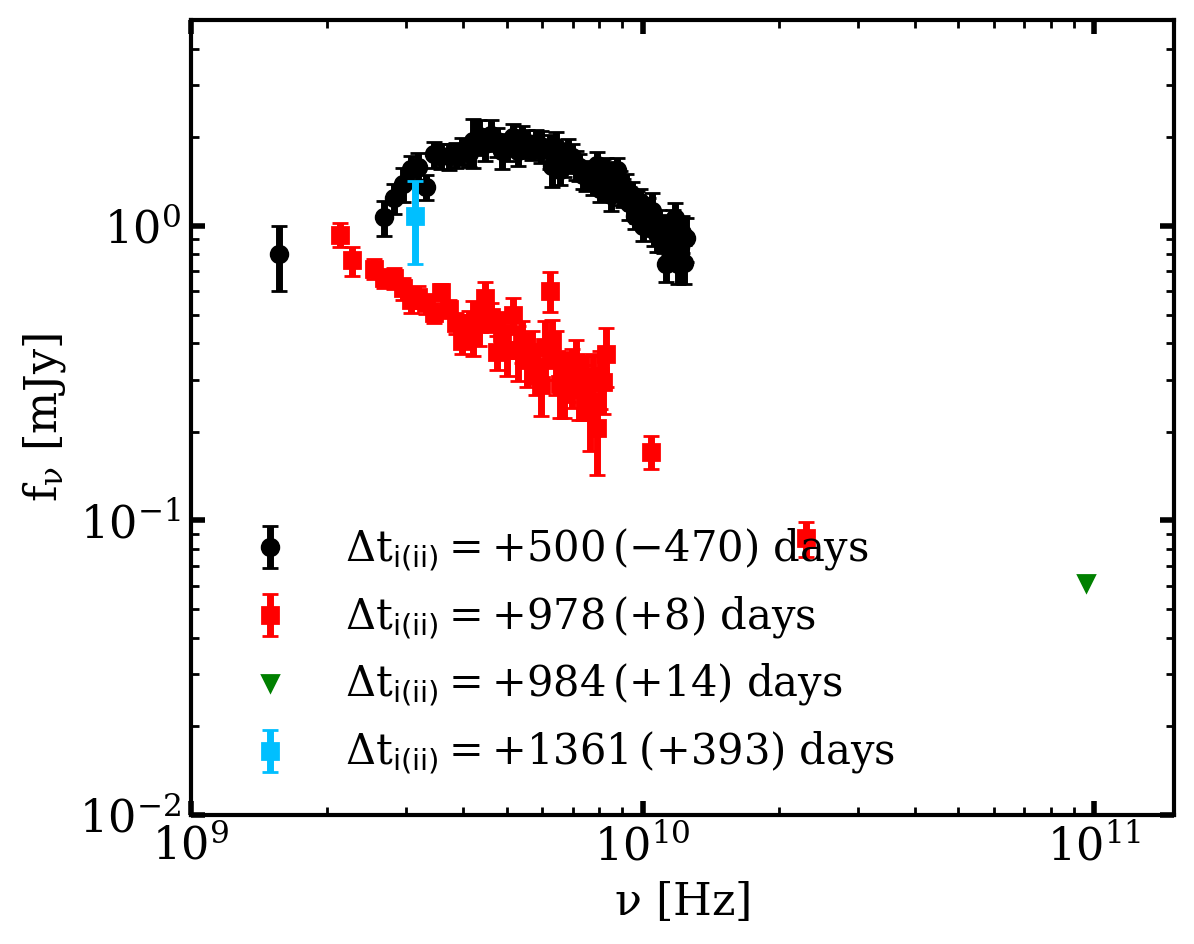

In [3]:
import json

import numpy as np

import matplotlib.pyplot as plt


vlai = [[1.5e9, 0.8e-3, 0.2e-3]] # L band

for f in list('CSX'): # skip the stored L band because the individual spw imaging looked bad

    data = json.load(open(f'vdq_vla/59612/{f}_fluxes.json', 'r'))

    for k in data.keys(): 
        
        data[k] = np.array(data[k])
    
    mask = (data['freq']>(2.5e9 if f=='S' else 0))*(data['flux_err']>0)
    
    vlai.extend(list(np.array([data['freq'], data['flux'], data['flux_err']]).T[mask]))
    
vlai = np.array(vlai)
    
vlai = vlai[(vlai[:,2]>0)*(vlai[:,1]>0)]


vlaii = []

for f in list('CS')+['X0', 'K0']:

    data = json.load(open(f'vdq_vla/60090/{f}_fluxes.json', 'r'))
    
    vlaii.extend(list(np.array([data['freq'], data['flux'], data['flux_err']]).T))

vlaii = np.array(vlaii)

vlaii = vlaii[(vlaii[:,2]>0)*(vlaii[:,1]>0)]


plt.figure(figsize=(10/1.6,8/1.6))

z = 0.04463036101750584

plt.errorbar(vlai[:,0]*(1+z), vlai[:,1]*1e3, yerr=vlai[:,2]*1e3, fmt='ko', label='$\\Delta t_{\\rm i (ii)} = +500\,(-470)$ days')

# plt.errorbar([1.5e9*(1+z)],[0.8], yerr=[0.2], fmt='ko')

plt.errorbar(vlaii[:,0]*(1+z), vlaii[:,1]*1e3, yerr=vlaii[:,2]*1e3, fmt='rs', label='$\\Delta t_{\\rm i (ii)} = +978\,(+8)$ days')




# NOEMA

plt.errorbar(95.7e9, 5*0.0123, fmt='gv', label='$\\Delta t_{\\rm i (ii)} = +984\,(+14)$ days')




# VLASS E3

plt.errorbar(3e9*(1+z), 1.08, yerr=0.34, fmt='s', c='deepskyblue', label='$\\Delta t_{\\rm i (ii)} = +1361\,(+393)$ days', zorder=10)




plt.legend(fontsize=15)

plt.loglog()

plt.xlabel('$\\nu$ [Hz]')

plt.ylabel('$f_\\nu$ [mJy]')

plt.xlim(1e9,150e9)

plt.ylim(1e-2,5)

plt.show()


60473

In [25]:
from otter import util
import pandas as pd
from astropy import units as u

data = dict(
    name = "2020vdq",
    bibcode = "2025ApJ...985..175S",
    date = [],
    date_format = "mjd",
    flux = [],
    flux_err = [],
    flux_unit = "mJy",
    # filter = [],
    filter_eff = [],
    filter_eff_units = "Hz",
    telescope = "VLA"
)

data["filter_eff"] += list(vlai[:,0])
data["flux"] += list(vlai[:,1])
data["flux_err"] += list(vlai[:,2])
data["date"] += [59612]*len(vlai)

data["filter_eff"] += list(vlaii[:,0])
data["flux"] += list(vlaii[:,1])
data["flux_err"] += list(vlaii[:,2])
data["date"] += [60090]*len(vlaii)

df = pd.DataFrame(data)

df["filter"] = util.freqlist_to_band(df.filter_eff.tolist(), [u.Hz]*len(df))
df["upperlimit"] = False

data2 = dict(
        name = "2020vdq",
    bibcode = "2025ApJ...985..175S",
    date = [59612+984-500, 59612+1361-500],
    date_format = "mjd",
    flux = [3*0.0123, 1.08],
    upperlimit = [True, False],
    flux_err = [0, 0.34],
    flux_unit = "mJy",
    # filter = [],
    filter_eff = [95.7e9, 3e9*(1+z)],
    filter_eff_units = "Hz",
    telescope = ["NOEMA", "VLASS"]
)
df2 = pd.DataFrame(data2)
df2["filter"] = util.freqlist_to_band(df2.filter_eff.tolist(), [u.Hz]*len(df))

vdq = pd.concat([df, df2]).reset_index(drop=True)

In [27]:
vdq.to_csv("2020vdq-otter.csv")